<a href="https://colab.research.google.com/github/fauzanyusaadicandra/32-pbk-uts-233510211/blob/main/Copy_of_project_BOOM_BGT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##**Pengumpulan dan Akuisisi Data, Data Cleaning, serta Exploratory Data Analysis (EDA)**


**Jenis Data yang Digunakan:**

Dataset yang digunakan adalah Retail Store Sales Dataset yang berisi data transaksi penjualan barang di beberapa lokasi toko, termasuk informasi item, harga, jumlah, metode pembayaran, dan tanggal transaksi.

**Jenis-Jenis Data:**

- Data Numerik

- Quantity → jumlah barang yang dibeli per transaksi

- Price Per Unit → harga per unit barang

- Total Spent → total pengeluaran per transaksi

**Data Kategorikal:**

- Item → nama barang

- Category → kategori barang (misal: FURNITURE, FOOD, BEVERAGE)

- Payment Method → metode pembayaran (misal: Cash, Credit Card)

- Location → lokasi toko

**Data Tanggal:**

- Transaction Date → tanggal transaksi

Dataset ini digunakan untuk menganalisis pola penjualan, produk yang paling laku, pendapatan per item dan per lokasi, serta tren penjualan per bulan.

## Jenis Dataset:

Dataset Retail Store Sales termasuk dalam jenis project regresi karena analisis yang dilakukan berfokus pada data berbentuk angka, seperti Quantity, Price Per Unit, dan Total Spent. Total Spent dijadikan target karena merupakan nilai akhir dari transaksi yang dipengaruhi oleh berbagai variabel numerik dan kategorikal, serta berbentuk data kontinu. Oleh karena itu, pendekatan yang tepat untuk dataset ini adalah regresi.

## 1. Import & Download Dataset

link Kaggle : https://www.kaggle.com/datasets/ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning

In [ ]:
import kagglehub

# Download dataset Retail Store Sales (Dirty Data)
dspath = kagglehub.dataset_download(
    "ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning"
)

print("Dataset downloaded at:", dspath)


Using Colab cache for faster access to the 'retail-store-sales-dirty-for-data-cleaning' dataset.
Dataset downloaded at: /kaggle/input/retail-store-sales-dirty-for-data-cleaning


In [ ]:
# Load CSV file
import os
import pandas as pd
import numpy as np

file_path = os.path.join(dspath, "retail_store_sales.csv")
df = pd.read_csv(file_path)

# Tampilkan data awal
df


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [ ]:
# IDENTIFIKASI TIPE DATA (NUMERIK & KATEGORIKAL)
print("=== Identifikasi Kolom Numerik dan Kategorikal ===\n")

# Kolom numerik
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()

# Kolom kategorikal (object/category)
kolom_kategorikal = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Kolom Numerik:")
for col in kolom_numerik:
    print(" -", col)

print("\nKolom Kategorikal:")
for col in kolom_kategorikal:
    print(" -", col)


=== Identifikasi Kolom Numerik dan Kategorikal ===

Kolom Numerik:
 - Price Per Unit
 - Quantity
 - Total Spent

Kolom Kategorikal:
 - Transaction ID
 - Customer ID
 - Category
 - Item
 - Payment Method
 - Location
 - Transaction Date
 - Discount Applied


## 2. Basic Info & Missing Values Check

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
print(df.isna().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


## 3. Cleaning Step 1: Standardizing Invalid Values

### 3.1 Cek dulu nilai-nilai yang bermasalah per kolom

In [ ]:
cols_to_check = [
    "Item",
    "Quantity",
    "Price Per Unit",
    "Payment Method",
    "Location",
    "Transaction Date"
]

for col in cols_to_check:
    print(f"\n===== Unique values in {col} =====")
    print(df[col].dropna().unique()[:50])



===== Unique values in Item =====
['Item_10_PAT' 'Item_17_MILK' 'Item_12_BUT' 'Item_16_BEV' 'Item_6_FOOD'
 'Item_1_FOOD' 'Item_16_FUR' 'Item_22_BUT' 'Item_3_BUT' 'Item_2_FOOD'
 'Item_24_PAT' 'Item_16_MILK' 'Item_17_PAT' 'Item_13_EHE' 'Item_7_BEV'
 'Item_4_EHE' 'Item_10_FOOD' 'Item_14_FUR' 'Item_20_BUT' 'Item_25_FUR'
 'Item_14_FOOD' 'Item_22_PAT' 'Item_11_FOOD' 'Item_6_PAT' 'Item_21_EHE'
 'Item_25_BEV' 'Item_23_FOOD' 'Item_10_FUR' 'Item_11_BEV' 'Item_23_BUT'
 'Item_22_BEV' 'Item_10_EHE' 'Item_24_BUT' 'Item_8_BEV' 'Item_3_FOOD'
 'Item_12_FOOD' 'Item_16_CEA' 'Item_11_PAT' 'Item_16_BUT' 'Item_5_CEA'
 'Item_19_MILK' 'Item_23_FUR' 'Item_7_FUR' 'Item_15_CEA' 'Item_6_MILK'
 'Item_24_CEA' 'Item_22_CEA' 'Item_22_FOOD' 'Item_2_BUT' 'Item_14_PAT']

===== Unique values in Quantity =====
[10.  9.  2.  7.  8.  1.  3.  6.  4.  5.]

===== Unique values in Price Per Unit =====
[18.5 29.  21.5 27.5 12.5  5.  33.5 36.5  8.   6.5 39.5 24.5 23.  35.
 14.   9.5 41.  20.  38.  15.5 11.  32.  26.  30.5 17. ]


### 3.2 Standardisasi nilai invalid

In [ ]:
# Standarisasi nilai tidak valid menjadi NaN
invalid_values = ["UNKNOWN", "ERROR", "None", "NONE", "null", "", " "]
df = df.replace(invalid_values, np.nan)

# Konversi kolom numerik
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

# Konversi kolom tanggal
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

print("INFO:")
df.info()

print("\nTOTAL NILAI NULL:")
print(df.isna().sum())


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11362 non-null  object        
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB

TOTAL NILAI NULL:
Transaction ID         0
Customer ID            0
Category               0
Item              

## 4. Cleaning Step 2: Handling Missing Values

In [ ]:
# ===============================
# FILL MISSING VALUES SESUAI DATASET
# ===============================

# Fill numeric NaN dengan median
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

# Fill categorical NaN dengan mode
categorical_cols = ["Item", "Payment Method", "Location", "Category"]
for c in categorical_cols:
    df[c] = df[c].fillna(df[c].mode()[0])  # isi dengan nilai paling sering muncul

# Handle missing Total Spent
df.loc[df["Total Spent"].isna(), "Total Spent"] = df["Quantity"] * df["Price Per Unit"]

# Handle Transaction Date
median_date = df["Transaction Date"].median()
df["Transaction Date"] = df["Transaction Date"].fillna(median_date)

# Handle Discount Applied → isi "No" jika kosong
df["Discount Applied"] = df["Discount Applied"].fillna("No")

print("INFO DATASET SETELAH IMPUTASI")
df.info()

print("\nTOTAL NILAI NULL SETELAH IMPUTASI")
print(df.isna().sum())


INFO DATASET SETELAH IMPUTASI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB

TOTAL NILAI NULL SETELAH IMPUTASI
Transaction ID      0
Customer ID         0
Category 

## 5. Feature Engineering

In [ ]:
df["Transaction Date"]

,Transaction Date
0,2024-04-08
1,2023-07-23
2,2022-10-05
3,2022-05-07
4,2022-10-02
...,...
12570,2023-09-03
12571,2022-08-12
12572,2024-08-24
12573,2023-12-30


In [ ]:
# ===============================
# FEATURE ENGINEERING – TIME COLUMNS
# ===============================

df["Transaction Month"] = df["Transaction Date"].dt.month
df["Transaction Weekday"] = df["Transaction Date"].dt.day_name()

print("INFO DATASET SETELAH FEATURE ENGINEERING")
df.info()

print("\nTOTAL NILAI NULL SETELAH FEATURE ENGINEERING")
print(df.isna().sum())


INFO DATASET SETELAH FEATURE ENGINEERING
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       12575 non-null  object        
 1   Customer ID          12575 non-null  object        
 2   Category             12575 non-null  object        
 3   Item                 12575 non-null  object        
 4   Price Per Unit       12575 non-null  float64       
 5   Quantity             12575 non-null  float64       
 6   Total Spent          12575 non-null  float64       
 7   Payment Method       12575 non-null  object        
 8   Location             12575 non-null  object        
 9   Transaction Date     12575 non-null  datetime64[ns]
 10  Discount Applied     12575 non-null  object        
 11  Transaction Month    12575 non-null  int32         
 12  Transaction Weekday  12575 non-null  object    

In [ ]:
df["Transaction Month"]

,Transaction Month
0,4
1,7
2,10
3,5
4,10
...,...
12570,9
12571,8
12572,8
12573,12


In [ ]:
df["Transaction Weekday"]

,Transaction Weekday
0,Monday
1,Sunday
2,Wednesday
3,Saturday
4,Sunday
...,...
12570,Sunday
12571,Friday
12572,Saturday
12573,Saturday


## 6. Exploratory Data Analysis (EDA)

### 6.1 Summary Statistics

In [ ]:
print(df.describe())

       Price Per Unit      Quantity   Total Spent  \
count    12575.000000  12575.000000  12575.000000   
mean        23.348191      5.558648    130.208111   
min          5.000000      1.000000      5.000000   
25%         14.000000      3.000000     52.000000   
50%         23.000000      6.000000    110.000000   
75%         32.000000      8.000000    192.000000   
max         41.000000     10.000000    410.000000   
std         10.480413      2.790160     93.580667   

                    Transaction Date  Transaction Month  
count                          12575       12575.000000  
mean   2023-07-12 20:23:41.105368064           6.366441  
min              2022-01-01 00:00:00           1.000000  
25%              2022-09-30 00:00:00           3.000000  
50%              2023-07-13 00:00:00           6.000000  
75%              2024-04-24 00:00:00           9.000000  
max              2025-01-18 00:00:00          12.000000  
std                              NaN           3.503156  


### 6.2 Item Frequency Plot

/tmp/ipython-input-445303017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


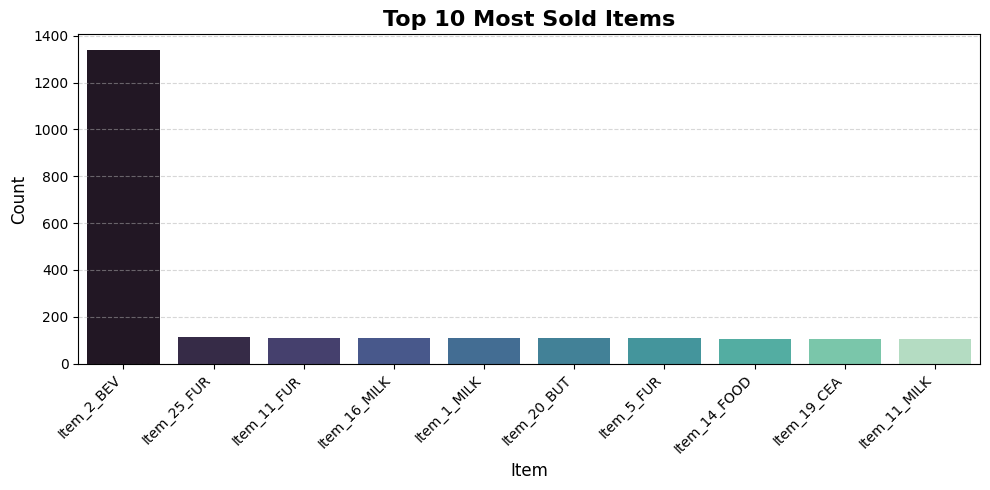

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil 10 item teratas
top_items = df["Item"].value_counts().head(10)

# PALETTE BIRU–UNGU
blue_purple_palette = sns.color_palette("mako", 10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_items.index,
    y=top_items.values,
    palette=blue_purple_palette
)

plt.title("Top 10 Most Sold Items", fontsize=16, fontweight="bold")
plt.xlabel("Item", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Item Frequency**

Tujuan:

- Mengetahui produk yang paling sering muncul dalam transaksi pelanggan.

- Mengidentifikasi item dengan permintaan tertinggi (paling populer) dan terendah dalam daftar unggulan.

- Membantu dalam pengambilan keputusan stok, penempatan produk, dan strategi promosi berdasarkan kategori (seperti BEV, FUR, MILK).

Insight Contoh:

- Item_2_BEV adalah produk yang paling populer dengan frekuensi mencapai 1.339 transaksi, jauh melampaui item lainnya. Sementara itu, di jajaran sepuluh besar, Item_11_MILK berada di posisi terbawah dengan 106 transaksi.

### 6.3 Payment Method Distribution

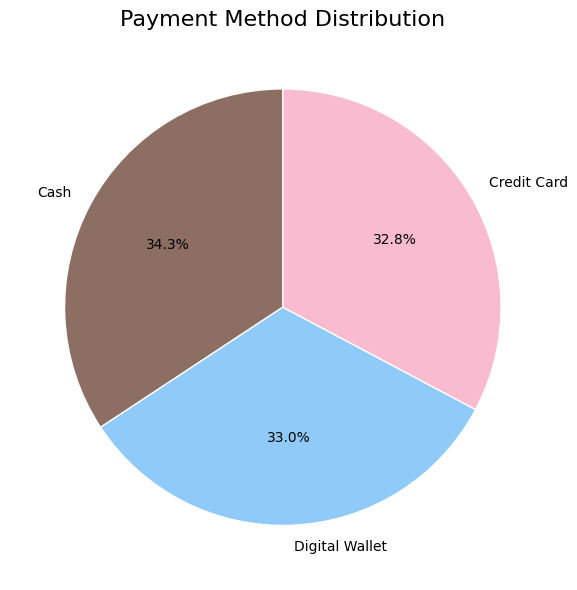

PAYMENT METHOD FREQUENCY (VALUE COUNTS)
Cash : 4310
Digital Wallet : 4144
Credit Card : 4121


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# PAYMENT METHOD FREQUENCY – PIE CHART
# ===============================

pm_counts = df["Payment Method"].value_counts()

# 3 WARNA AESTHETIC (PASTEL)
colors = [
    "#8D6E63", "#90CAF9", "#F8BBD0"]

plt.figure(figsize=(6,6))
plt.pie(
    pm_counts.values,
    labels=pm_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Payment Method Distribution", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

# ===============================
# PRINT PAYMENT METHOD FREQUENCY
# ===============================
print("PAYMENT METHOD FREQUENCY (VALUE COUNTS)")
for method, value in pm_counts.items():
    print(f"{method} : {value}")


**Payment Method Count**

Tujuan:

- Menganalisis preferensi metode pembayaran pelanggan saat melakukan transaksi.

- Menentukan sistem transaksi yang paling banyak digunakan dalam operasional bisnis.

- Menjadi dasar pertimbangan jika bisnis ingin memperbanyak fasilitas pembayaran tertentu atau memberikan promo khusus pada metode pembayaran tertentu.

Insight Contoh:

- Metode pembayaran Cash (Tunai) masih menjadi yang paling sering digunakan dengan 4.310 transaksi, namun perbedaannya sangat tipis dengan metode cashless seperti Digital Wallet (4.144) dan Credit Card (4.121), menunjukkan adopsi teknologi pembayaran digital yang sudah sangat tinggi.

### 6.4 Monthly Sales Trend

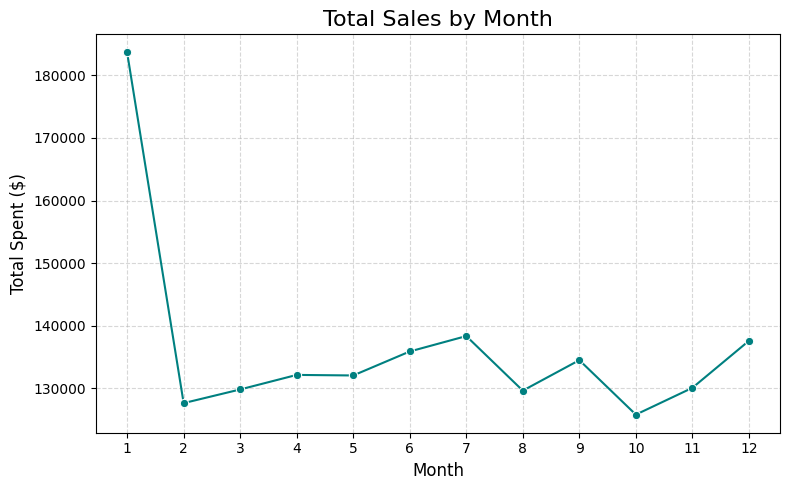

MONTHLY TOTAL SALES
Bulan 1 : $183,637.00
Bulan 2 : $127,662.00
Bulan 3 : $129,844.00
Bulan 4 : $132,164.50
Bulan 5 : $132,076.50
Bulan 6 : $135,906.00
Bulan 7 : $138,364.00
Bulan 8 : $129,656.50
Bulan 9 : $134,522.00
Bulan 10 : $125,827.50
Bulan 11 : $130,101.50
Bulan 12 : $137,605.50


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# TOTAL SALES PER MONTH – LINE PLOT

# Hitung total penjualan per bulan
monthly_sales = df.groupby("Transaction Month")["Total Spent"].sum()

# Plot
plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o", color="teal")
plt.title("Total Sales by Month", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Spent ($)", fontsize=12)
plt.xticks(monthly_sales.index)  # pastikan semua bulan terlihat
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("MONTHLY TOTAL SALES")
for month, value in monthly_sales.items():
    print(f"Bulan {month} : ${value:,.2f}")


**Monthly Sales Total**

Tujuan:

- Mengidentifikasi pola pendapatan penjualan berdasarkan bulan.

- Menentukan bulan dengan performa finansial tertinggi dan terendah.

- Membantu perencanaan alokasi anggaran promosi atau kampanye musiman agar lebih efektif.

Insight Contoh:

- Bulan 1 (Januari) memiliki pendapatan tertinggi dengan total $183,637.00, yang menunjukkan performa awal tahun yang sangat kuat. Sebaliknya, Bulan 10 (Oktober) mencatatkan pendapatan terendah sebesar $125,827.50.

### 6.5 Top 10 most sold per Item (BARPLOT)

/tmp/ipython-input-1354497417.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


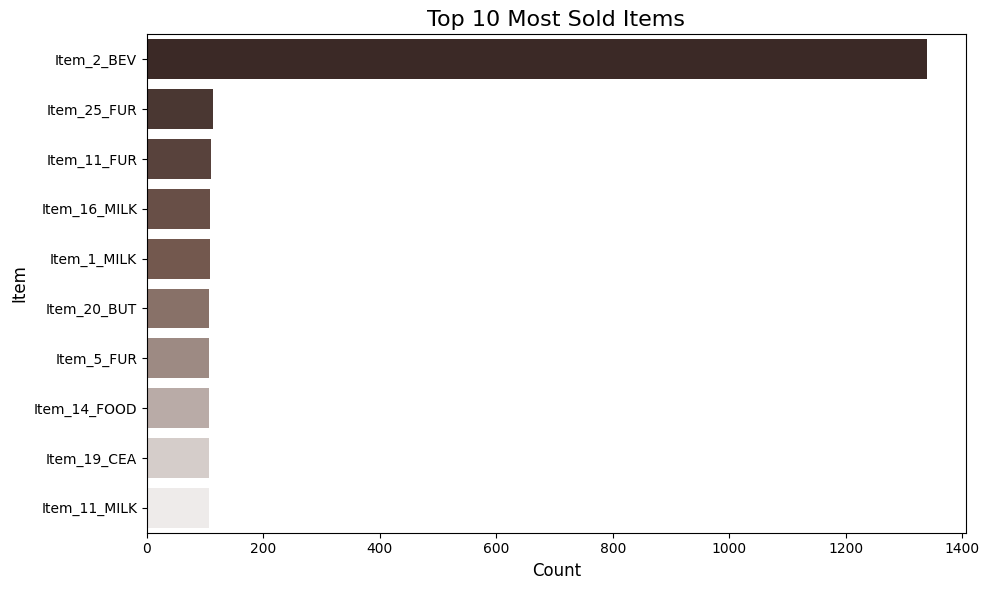

TOP 10 ITEM FREQUENCY
Item_2_BEV : 1339
Item_25_FUR : 113
Item_11_FUR : 110
Item_16_MILK : 109
Item_1_MILK : 109
Item_20_BUT : 107
Item_5_FUR : 107
Item_14_FOOD : 106
Item_19_CEA : 106
Item_11_MILK : 106


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil 10 item teratas
top_items = df["Item"].value_counts().head(10)

# PALETTE GRADASI COKLAT (gelap → terang)
brown_palette = [
    "#3E2723",  # coklat sangat gelap
    "#4E342E",
    "#5D4037",
    "#6D4C41",
    "#795548",
    "#8D6E63",
    "#A1887F",
    "#BCAAA4",
    "#D7CCC8",
    "#EFEBE9"   # coklat sangat terang
]

# Plot horizontal bar
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_items.values,
    y=top_items.index,
    palette=brown_palette
)

plt.title("Top 10 Most Sold Items", fontsize=16)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Item", fontsize=12)
plt.tight_layout()
plt.show()

# Print tabel
print("TOP 10 ITEM FREQUENCY")
for item, value in top_items.items():
    print(f"{item} : {value}")


**Top 10 most sold per Item**

Tujuan:

- Mengetahui produk mana yang menghasilkan pendapatan terbesar bagi bisnis.

- Menentukan item prioritas untuk strategi pemasaran, pengadaan, dan program bundling.

- Mengukur kontribusi masing-masing item terhadap total pendapatan keseluruhan.

Insight Contoh:

- Item_2_BEV memberikan kontribusi pendapatan terbesar dengan nilai 1.339, sedangkan Item_11_MILK mencatatkan pendapatan terendah di jajaran sepuluh besar ini dengan nilai 106.

## 6.6 QUANTITY DISTRIBUTION (HISTOGRAM)

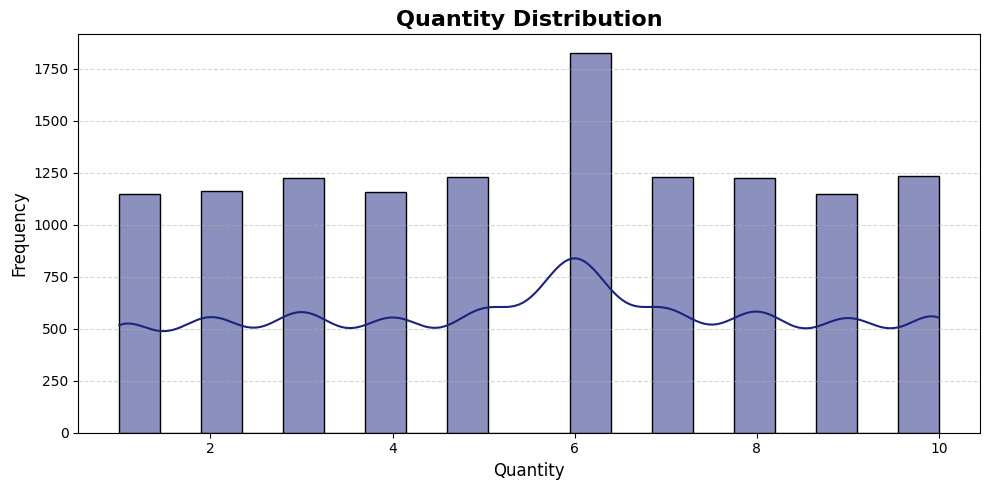


QUANTITY DESCRIPTIVE STATISTICS
Count : 12575
Mean  : 5.56
Std   : 2.79
Min   : 1
25%   : 3
50%   : 6
75%   : 8
Max   : 10


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# HISTOGRAM QUANTITY (COKLAT TUA)
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# HISTOGRAM QUANTITY (NAVY)
# ===============================
plt.figure(figsize=(10,5))
sns.histplot(
    df["Quantity"],
    bins=20,
    kde=True,
    color="#1A237E"   # NAVY BIRU TUA
)

plt.title("Quantity Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Quantity", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# ===============================
# DESCRIPTIVE STATISTICS QUANTITY
# ===============================
desc = df["Quantity"].describe()

print("\nQUANTITY DESCRIPTIVE STATISTICS")
print(f"Count : {desc['count']:.0f}")
print(f"Mean  : {desc['mean']:.2f}")
print(f"Std   : {desc['std']:.2f}")
print(f"Min   : {desc['min']:.0f}")
print(f"25%   : {desc['25%']:.0f}")
print(f"50%   : {desc['50%']:.0f}")
print(f"75%   : {desc['75%']:.0f}")
print(f"Max   : {desc['max']:.0f}")


**Quantity Descriptive Statistics**

Tujuan:

- Menganalisis distribusi jumlah pembelian per transaksi.

- Mengetahui rata-rata quantity dan variasinya untuk memahami perilaku belanja pelanggan.

- Menjadi dasar untuk estimasi kebutuhan stok harian dan perencanaan logistik.

Insight Contoh:

- Rata-rata pembelian per transaksi adalah sekitar 5,56 unit dengan jumlah pembelian maksimum sebesar 10 unit. Hal ini menunjukkan bahwa pelanggan cenderung membeli dalam jumlah kecil hingga menengah (ritel) secara konsisten.

## 6.7 PRICE PER UNIT DISTRIBUTION (HIST + KDE)

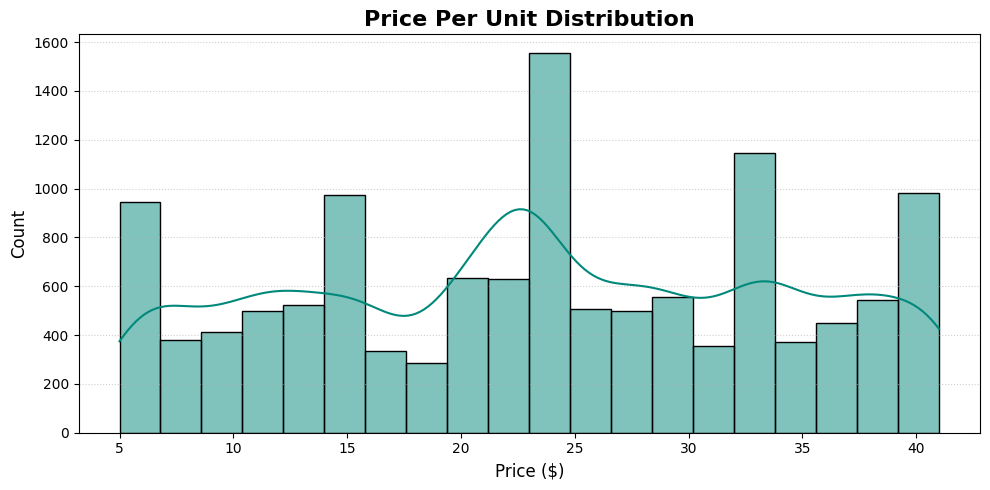


PRICE PER UNIT DESCRIPTIVE STATISTICS
Count : 12575
Mean  : 23.35
Std   : 10.48
Min   : 5
25%   : 14
50%   : 23
75%   : 32
Max   : 41


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# HISTOGRAM PRICE PER UNIT
# ===============================
plt.figure(figsize=(10,5))
sns.histplot(
    df["Price Per Unit"],
    bins=20,
    kde=True,
    color="#00897B"   # TOSCA
)

plt.title("Price Per Unit Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ===============================
# DESCRIPTIVE STATISTICS PRICE PER UNIT
# ===============================
desc = df["Price Per Unit"].describe()

print("\nPRICE PER UNIT DESCRIPTIVE STATISTICS")
print(f"Count : {desc['count']:.0f}")
print(f"Mean  : {desc['mean']:.2f}")
print(f"Std   : {desc['std']:.2f}")
print(f"Min   : {desc['min']:.0f}")
print(f"25%   : {desc['25%']:.0f}")
print(f"50%   : {desc['50%']:.0f}")
print(f"75%   : {desc['75%']:.0f}")
print(f"Max   : {desc['max']:.0f}")


**Price Per Unit Descriptive Statistics**

Tujuan:

- Melihat sebaran harga produk untuk memahami segmentasi harga pasar.

- Menilai kesesuaian harga dengan variasi item yang tersedia dalam katalog.

- Mengecek apakah terdapat outlier (pencilan) atau harga yang tidak wajar dalam sistem.

Insight Contoh:

- Harga rata-rata per unit produk adalah 23,35 dengan rentang harga antara 5 hingga 41. Hal ini menunjukkan variasi harga produk yang cukup beragam namun tetap berada dalam batas yang wajar tanpa adanya nilai ekstrem.

## 6.8 HEATMAP CORRELATION

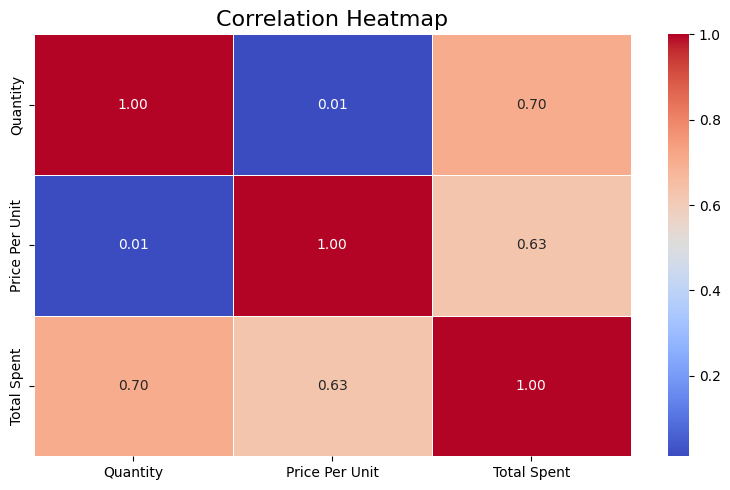


CORRELATION MATRIX
                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.011306     0.703938
Price Per Unit  0.011306        1.000000     0.625595
Total Spent     0.703938        0.625595     1.000000

CORRELATION VALUES
Quantity vs Price Per Unit       : 0.01
Quantity vs Total Spent          : 0.70
Price Per Unit vs Total Spent    : 0.63


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# HITUNG KORELASI
corr = df[["Quantity", "Price Per Unit", "Total Spent"]].corr()

# HEATMAP
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# PRINT CORRELATION MATRIX
print("\nCORRELATION MATRIX")
print(corr)

# PRINT NILAI KORELASI SECARA INDIVIDUAL
print("\nCORRELATION VALUES")
print(f"Quantity vs Price Per Unit       : {corr.loc['Quantity','Price Per Unit']:.2f}")
print(f"Quantity vs Total Spent          : {corr.loc['Quantity','Total Spent']:.2f}")
print(f"Price Per Unit vs Total Spent    : {corr.loc['Price Per Unit','Total Spent']:.2f}")


## Interpretasi Nilai Korelasi

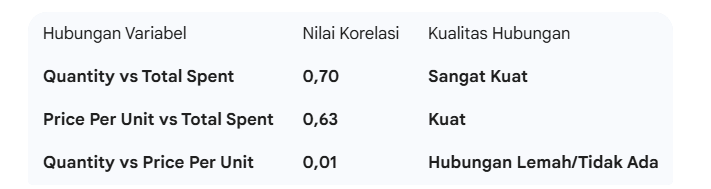

**Interpretasi Hasil:**

- Quantity vs Total Spent (0,70 - Sangat Kuat): Nilai ini menunjukkan pola yang sangat konsisten di mana semakin banyak jumlah barang yang dimasukkan ke keranjang, semakin tinggi pula total bayar pelanggan. Strategi untuk meningkatkan kuantitas (seperti "Beli 2 Gratis 1") akan sangat efektif meningkatkan revenue.

- Price Per Unit vs Total Spent (0,63 - Kuat): Nilai ini menunjukkan bahwa produk-produk dengan harga lebih tinggi juga menyumbang secara signifikan pada total pendapatan. Ini membuktikan bahwa pelanggan tidak hanya membeli barang murah dalam jumlah banyak, tetapi juga bersedia membeli barang dengan nilai unit yang tinggi.

- Quantity vs Price Per Unit (0,01 - Hubungan Lemah): Korelasi yang mendekati nol ini sangat menarik. Ini artinya, baik barang itu murah maupun mahal, jumlah yang dibeli pelanggan cenderung tetap (tidak ada kecenderungan barang murah dibeli lebih banyak atau barang mahal dibeli lebih sedikit dalam satu baris transaksi). Hal ini menunjukkan elastisitas harga yang unik pada produk Anda.

**Tujuan:**

- Mengidentifikasi kekuatan hubungan antar variabel numerik (Quantity, Price per Unit, dan Total Spent).

- Menilai sejauh mana jumlah barang dan harga satuan memengaruhi total pengeluaran pelanggan.

- Memberikan dasar analisis untuk strategi penetapan harga dan prediksi penjualan di masa depan.

**Insight Contoh:**

- Quantity memiliki hubungan yang sangat kuat dengan Total Spent (0,70), menunjukkan bahwa peningkatan volume barang yang dibeli adalah pendorong utama pendapatan.

- Price Per Unit memiliki hubungan yang kuat dengan Total Spent (0,63), yang berarti harga barang juga berkontribusi signifikan terhadap total transaksi.

- Hubungan antara Quantity dan Price Per Unit hampir tidak ada (0,01), yang menandakan bahwa harga barang tidak memengaruhi jumlah unit yang dibeli pelanggan dalam satu transaksi.




## 6.9 Total Sales per Location

/tmp/ipython-input-3522808059.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


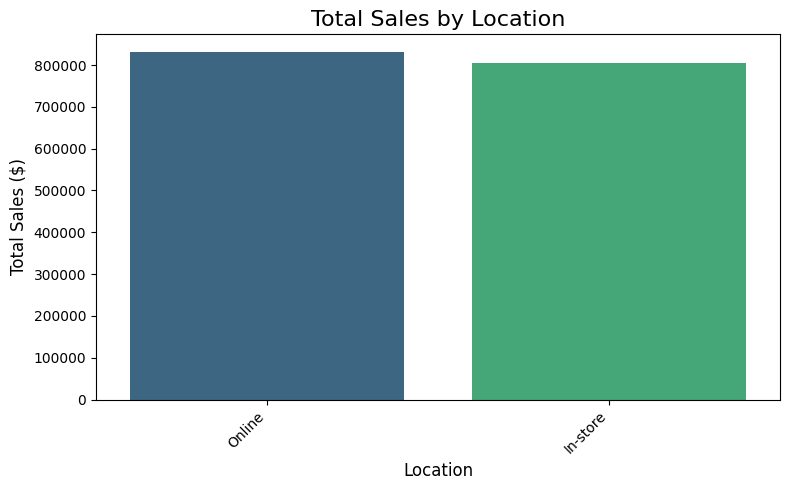

TOTAL SALES PER LOCATION
Online : $831,922.00
In-store : $805,445.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# TOTAL SALES PER LOCATION
# ===============================
location_sales = df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False)

# Plot vertical bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x=location_sales.index,
    y=location_sales.values,
    palette="viridis"   # WARNA MENARIK & ELEGAN
)

plt.title("Total Sales by Location", fontsize=16)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print tabel
print("TOTAL SALES PER LOCATION")
for loc, total in location_sales.items():
    print(f"{loc} : ${total:,.2f}")


**Total Sales per Location**

Tujuan:

- Mengetahui performa penjualan berdasarkan saluran atau lokasi transaksi dilakukan.

- Membantu menentukan prioritas alokasi sumber daya antara operasional digital dan fisik.

- Mengidentifikasi saluran mana yang menghasilkan kontribusi pendapatan (profit) terbesar bagi bisnis.

Insight Contoh:

- Saluran Online mencatatkan pendapatan tertinggi sebesar 831,922.00, sedikit melampaui penjualan In-store yang berjumlah 805,445.00. Hal ini menunjukkan bahwa pelanggan sudah sangat nyaman bertransaksi secara digital, namun toko fisik masih memegang peran yang hampir sama pentingnya.

## 6.10 Total Spent Descriptive Statistics

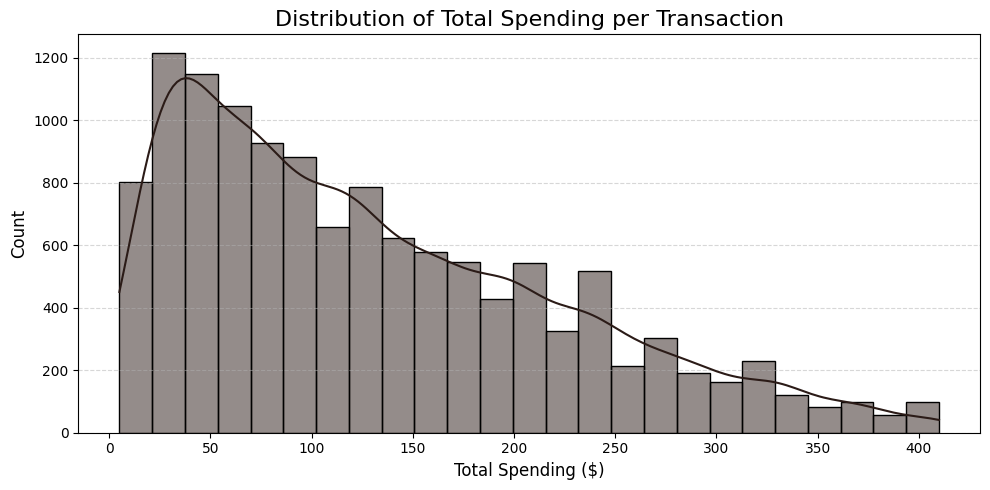


TOTAL SPENT DESCRIPTIVE STATISTICS
Count : 12575
Mean  : $130.21
Std   : $93.58
Min   : $5.00
25%   : $52.00
50%   : $110.00
75%   : $192.00
Max   : $410.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# HISTOGRAM TOTAL SPENT
# ===============================
plt.figure(figsize=(10,5))
sns.histplot(
    df["Total Spent"],
    bins=25,
    kde=True,
    color="#2B1B17"   # COKLAT SANGAT GELAP (ESPRESSO)
)

plt.title("Distribution of Total Spending per Transaction", fontsize=16)
plt.xlabel("Total Spending ($)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ===============================
# DESCRIPTIVE STATISTICS TOTAL SPENT
# ===============================
desc = df["Total Spent"].describe()

print("\nTOTAL SPENT DESCRIPTIVE STATISTICS")
print(f"Count : {desc['count']:.0f}")
print(f"Mean  : ${desc['mean']:.2f}")
print(f"Std   : ${desc['std']:.2f}")
print(f"Min   : ${desc['min']:.2f}")
print(f"25%   : ${desc['25%']:.2f}")
print(f"50%   : ${desc['50%']:.2f}")
print(f"75%   : ${desc['75%']:.2f}")
print(f"Max   : ${desc['max']:.2f}")


**Total Spent Descriptive Statistics**

Tujuan:

- Mengetahui sebaran total pengeluaran pelanggan per transaksi.

- Menentukan rentang (range) transaksi kategori kecil, sedang, dan besar.

- Membantu strategi upselling atau promosi yang disasarkan berdasarkan perilaku pengeluaran pelanggan.

Insight Contoh:

- Rata-rata pengeluaran per transaksi adalah sebesar 130,21.

- Sebagian besar transaksi berada di kisaran 52,00 hingga 192,00 (Q1–Q3).

- Variasi pengeluaran antar pelanggan sangat tinggi (std = 93,58), dengan nilai transaksi maksimum mencapai 410,00.

- Distribusi transaksi bersifat skewed-right (miring ke kanan), karena nilai rata-rata lebih besar dari median (130,21 > 110,00). Ini menunjukkan terdapat banyak transaksi dalam nilai kecil/menengah dan sedikit transaksi bernilai sangat besar.

## 6.11 EDA Dashboard

/tmp/ipython-input-2510189622.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


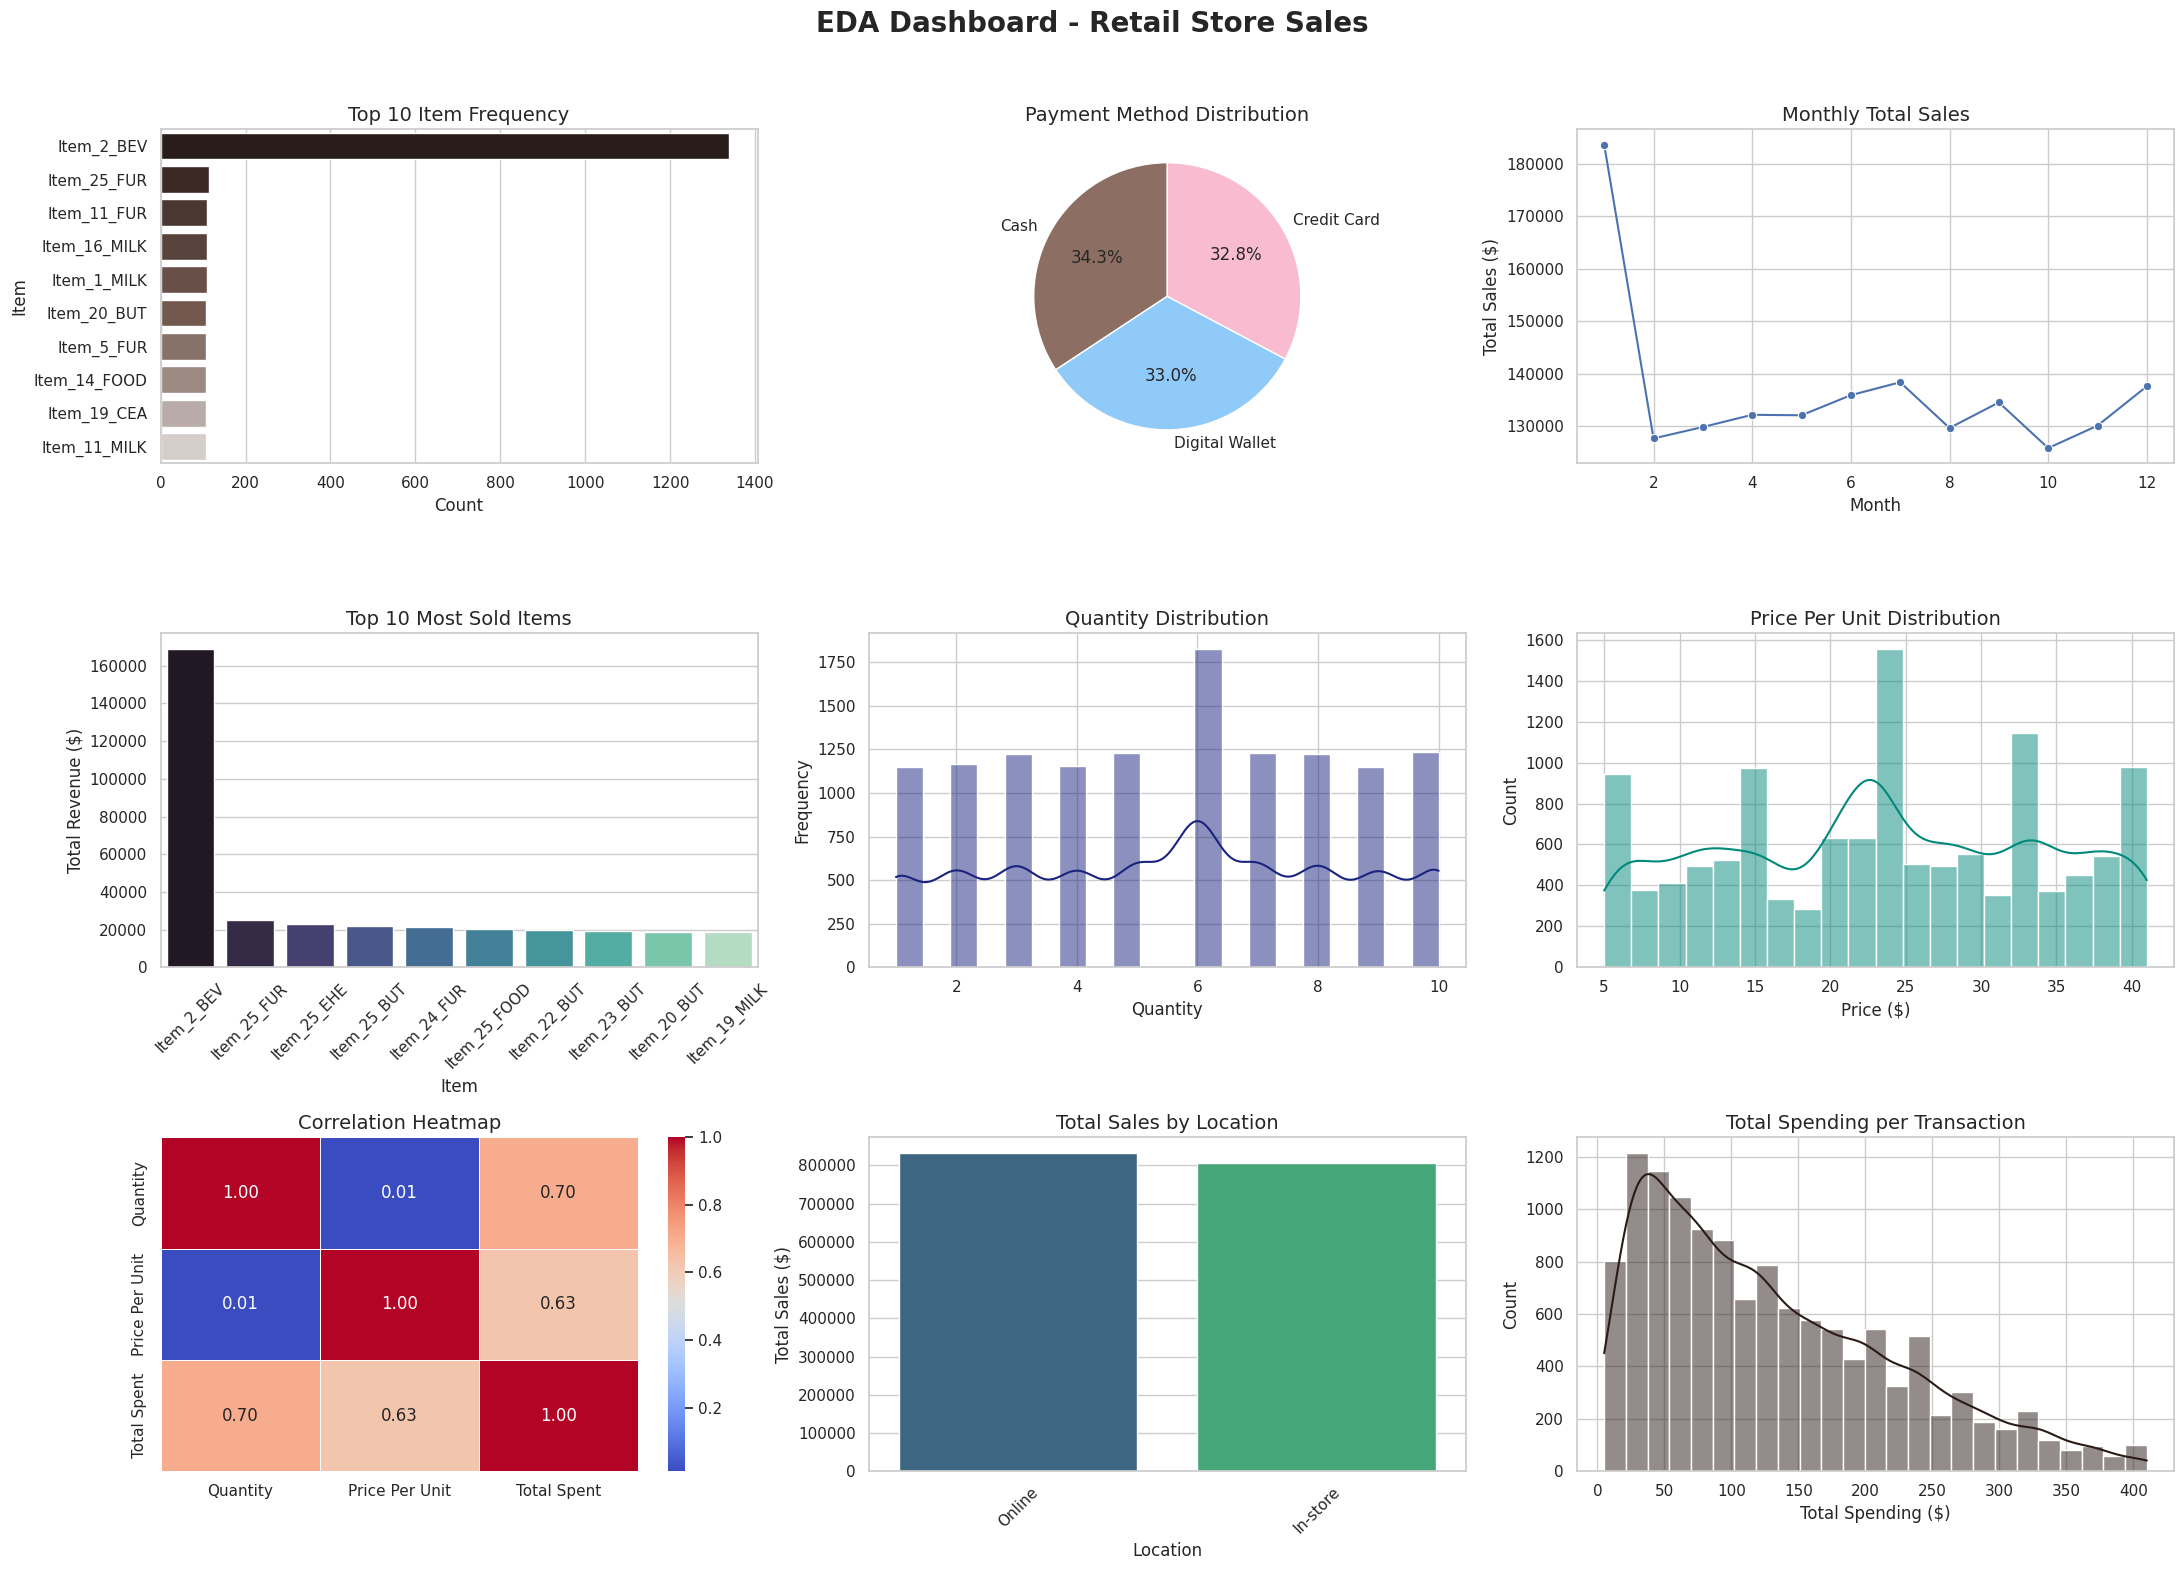

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import the os module

sns.set_theme(style="whitegrid")

# ===============================
# Load Dataset
# ===============================
# Use the globally available 'dspath' from the previous download step
file_path = os.path.join(dspath, "retail_store_sales.csv")
df = pd.read_csv(file_path)

# ===============================
# 2️⃣ Data Cleaning / Imputasi
# ===============================
invalid_values = ["UNKNOWN", "ERROR", "None", "NONE", "null", "", " "]
df = df.replace(invalid_values, np.nan)

# Numeric columns
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

# Date column
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Fill numeric NaN with median
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

# Fill categorical NaN with mode
categorical_cols = ["Item", "Payment Method", "Location", "Category"]
for c in categorical_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

# Handle missing Total Spent
df.loc[df["Total Spent"].isna(), "Total Spent"] = df["Quantity"] * df["Price Per Unit"]

# Handle missing Transaction Date
median_date = df["Transaction Date"].median()
df["Transaction Date"] = df["Transaction Date"].fillna(median_date)

# Add Month & Day of Week columns
df["Month"] = df["Transaction Date"].dt.month
df["Day of Week"] = df["Transaction Date"].dt.day_name()

# ===============================
# 3️⃣ Prepare Data for Plots
# ===============================

# Top 10 items by frequency
top_items = df["Item"].value_counts().head(10)

# Top 10 items by revenue
top_revenue_items = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).head(10)

# Monthly total sales
monthly_sales = df.groupby("Month")["Total Spent"].sum()

# Total sales by location
location_sales = df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False)

# Correlation
corr = df[["Quantity","Price Per Unit","Total Spent"]].corr()

# ===============================
# 4️⃣ Plot Dashboard 3x3
# ===============================
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.suptitle("EDA Dashboard - Retail Store Sales", fontsize=20, fontweight="bold")

# 1️⃣ Top 10 Item Frequency
sns.barplot(x=top_items.values, y=top_items.index, palette=[
        "#2B1B17", "#3E2723", "#4E342E", "#5D4037", "#6D4C41",
        "#795548", "#8D6E63", "#A1887F", "#BCAAA4", "#D7CCC8"
    ], ax=axes[0,0], hue=top_items.index, legend=False)
axes[0,0].set_title("Top 10 Item Frequency", fontsize=14)
axes[0,0].set_xlabel("Count")
axes[0,0].set_ylabel("Item")

# 2️⃣ Payment Method Distribution (Pie)
axes[0,1].pie(
    df["Payment Method"].value_counts(),
    labels=df["Payment Method"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#8D6E63", "#90CAF9", "#F8BBD0"]
)
axes[0,1].set_title("Payment Method Distribution", fontsize=14)


# 3️⃣ Monthly Total Sales (Line)
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o", ax=axes[0,2])
axes[0,2].set_title("Monthly Total Sales", fontsize=14)
axes[0,2].set_xlabel("Month")
axes[0,2].set_ylabel("Total Sales ($)")
axes[0,2].grid(True)

# 4️⃣ Top 10 Items by Total Revenue (Brown Gradient)
modern_palette = sns.color_palette("mako", 10)

sns.barplot(
    x=top_revenue_items.index,
    y=top_revenue_items.values,
    palette=modern_palette,
    ax=axes[1,0]
)


axes[1,0].set_title("Top 10 Most Sold Items", fontsize=14)
axes[1,0].set_xlabel("Item")
axes[1,0].set_ylabel("Total Revenue ($)")
axes[1,0].tick_params(axis="x", rotation=45)

# 5️⃣ Quantity Distribution
sns.histplot(df["Quantity"], bins=20, kde=True, color="#1A237E", ax=axes[1,1])
axes[1,1].set_title("Quantity Distribution", fontsize=14)
axes[1,1].set_xlabel("Quantity")
axes[1,1].set_ylabel("Frequency")

# 6️⃣ Price Per Unit Distribution
sns.histplot(df["Price Per Unit"], bins=20, kde=True, color="#00897B", ax=axes[1,2])
axes[1,2].set_title("Price Per Unit Distribution", fontsize=14)
axes[1,2].set_xlabel("Price ($)")
axes[1,2].set_ylabel("Count")

# 7️⃣ Correlation Heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes[2,0])
axes[2,0].set_title("Correlation Heatmap", fontsize=14)

# 8️⃣ Total Sales by Location
sns.barplot(x=location_sales.index, y=location_sales.values, palette="viridis", ax=axes[2,1], hue=location_sales.index, legend=False)
axes[2,1].set_title("Total Sales by Location", fontsize=14)
axes[2,1].set_xlabel("Location")
axes[2,1].set_ylabel("Total Sales ($)")
axes[2,1].tick_params(axis="x", rotation=45)

# 9️⃣ Total Spent Distribution
sns.histplot(df["Total Spent"], bins=25, kde=True, color="#2B1B17", ax=axes[2,2])
axes[2,2].set_title("Total Spending per Transaction", fontsize=14)
axes[2,2].set_xlabel("Total Spending ($)")
axes[2,2].set_ylabel("Count")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

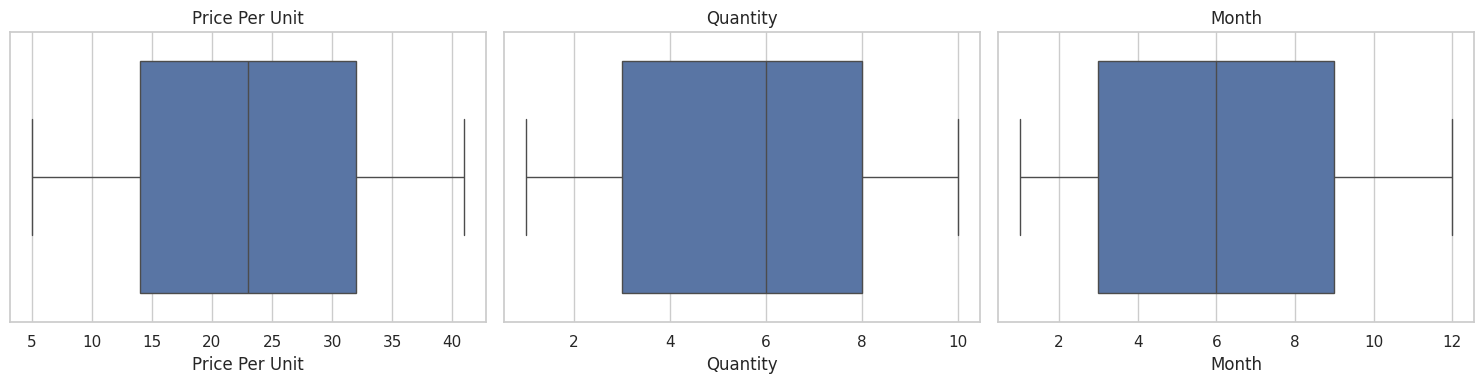

In [ ]:
# ===============================
# BOXPLOT VARIABEL NUMERIK
# ===============================

# Ambil kolom numerik (kecuali target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Total Spent')

# Tentukan jumlah baris subplot
rows = int(np.ceil(len(numeric_cols) / 3))

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


##Price Per Unit – Descriptive Statistics
Tujuan:

- Mengetahui sebaran harga produk yang dijual per unit.

- Mengidentifikasi rentang harga produk murah, menengah, dan mahal.

- Membantu strategi penetapan harga dan segmentasi produk.

Insight:

- Rata-rata harga per unit berada pada kisaran ±23, menunjukkan dominasi produk dengan harga menengah.

- Sebagian besar harga produk berada dalam rentang ±15 hingga ±30 (Q1–Q3).

- Variasi harga cukup tinggi, mengindikasikan keberagaman produk dengan tingkat harga berbeda.

- Distribusi harga cenderung right-skewed, karena nilai maksimum lebih jauh dari median, yang menunjukkan keberadaan beberapa produk dengan harga relatif tinggi.

##Quantity – Descriptive Statistics
Tujuan:

- Mengetahui pola jumlah pembelian pelanggan per transaksi.

- Mengidentifikasi transaksi pembelian kecil, sedang, dan besar.

- Mendukung strategi bundling atau promosi pembelian dalam jumlah tertentu.

Insight:

- Rata-rata jumlah pembelian per transaksi sekitar 6 unit.

- Mayoritas transaksi berada dalam rentang 3 hingga 8 unit (Q1–Q3).

- Variasi pembelian relatif moderat, tanpa adanya pembelian dalam jumlah ekstrem.

- Distribusi quantity relatif simetris hingga sedikit skewed-right, menandakan mayoritas pelanggan membeli dalam jumlah kecil hingga menengah.

##Month – Descriptive Statistics
Tujuan:

- Menganalisis distribusi waktu transaksi sepanjang tahun.

- Mengidentifikasi potensi pola musiman dalam transaksi penjualan.

- Mendukung perencanaan promosi berbasis waktu.

Insight:

- Rata-rata transaksi terjadi di sekitar bulan ke-6 (Juni).

- Sebagian besar transaksi tersebar antara bulan 3 hingga bulan 9 (Q1–Q3).

- Distribusi transaksi relatif merata sepanjang tahun.

- Tidak ditemukan skewness ekstrem, yang menunjukkan tidak adanya konsentrasi transaksi berlebihan pada bulan tertentu.

# PREPARE FEATURES , PIPELINE dan SPLIT DATA

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# ===============================
# PERSIAPAN DATA MODELING
# ===============================

df_model = df.copy()

# Target klasifikasi
target_col = 'spent_class'

# Create the 'spent_class' column based on 'Total Spent'
def categorize_spent(total_spent):
    if total_spent < df_model['Total Spent'].quantile(0.33):
        return 'rendah'
    elif total_spent < df_model['Total Spent'].quantile(0.66):
        return 'sedang'
    else:
        return 'tinggi'

df_model[target_col] = df_model['Total Spent'].apply(categorize_spent)

# X dan y (hindari data leakage)
X = df_model.drop(columns=[target_col, 'Total Spent'])
y = df_model[target_col]  # masih string: rendah/sedang/tinggi

# Identifikasi tipe fitur
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Kolom kategorikal:", cat_cols)
print("Kolom numerik:", num_cols)

# ===============================
# LABEL ENCODING TARGET
# ===============================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nMapping LabelEncoder:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls} --> {enc}")

# ===============================
# SPLIT DATA
# ===============================

X_train, X_test, y_train_str, y_test_str = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train = le.transform(y_train_str)
y_test  = le.transform(y_test_str)

# ===============================
# PREPROCESSOR
# ===============================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'
)


Kolom kategorikal: ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method', 'Location', 'Discount Applied', 'Day of Week']
Kolom numerik: ['Price Per Unit', 'Quantity', 'Month']

Mapping LabelEncoder:
rendah --> 0
sedang --> 1
tinggi --> 2


Tujuan

- Mengidentifikasi jenis fitur dalam dataset untuk menentukan metode preprocessing yang tepat.

- Mempersiapkan data agar dapat diproses oleh algoritma machine learning.

- Mengubah data kategorikal menjadi bentuk numerik tanpa menghilangkan makna kelas.

Insight

- Dataset terdiri dari kombinasi fitur kategorikal dan numerik, sehingga memerlukan tahapan preprocessing sebelum pemodelan.

- Penerapan Label Encoding berhasil mengonversi kategori target menjadi nilai numerik (rendah = 0, sedang = 1, tinggi = 2).

- Encoding ini memungkinkan proses klasifikasi berjalan efektif karena model dapat mengenali tingkatan nilai target secara terstruktur.

Train shape: (10060, 12) Test shape: (2515, 12)
Train class distribution:
 spent_class
tinggi    3466
rendah    3305
sedang    3289
Name: count, dtype: int64
Test class distribution:
 spent_class
tinggi    866
rendah    826
sedang    823
Name: count, dtype: int64

Tabel Distribusi Kelas Pengeluaran (Train vs Test):


,Kelas Pengeluaran,Train,Test
0,rendah,3305,826
1,sedang,3289,823
2,tinggi,3466,866


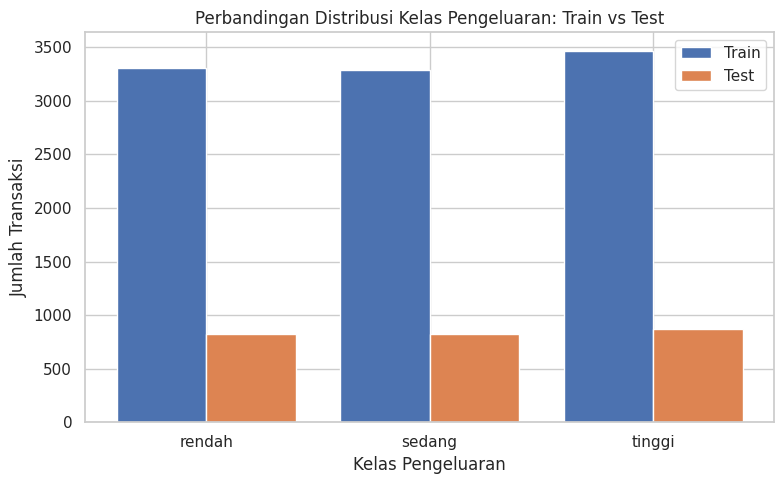

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:\n", y_train_str.value_counts())
print("Test class distribution:\n", y_test_str.value_counts())

# ===============================
# TABEL DISTRIBUSI KELAS
# ===============================

order = ['rendah', 'sedang', 'tinggi']

train_counts = y_train_str.value_counts().reindex(order)
test_counts  = y_test_str.value_counts().reindex(order)

tabel_distribusi = pd.DataFrame({
    'Kelas Pengeluaran': order,
    'Train': train_counts.values,
    'Test': test_counts.values
})

print("\nTabel Distribusi Kelas Pengeluaran (Train vs Test):")
display(tabel_distribusi)

# ===============================
# PLOT BAR
# ===============================

plt.figure(figsize=(8,5))
x = range(len(order))

plt.bar([i - 0.2 for i in x], train_counts, width=0.4, label='Train')
plt.bar([i + 0.2 for i in x], test_counts, width=0.4, label='Test')

plt.xticks(x, order)
plt.xlabel("Kelas Pengeluaran")
plt.ylabel("Jumlah Transaksi")
plt.title("Perbandingan Distribusi Kelas Pengeluaran: Train vs Test")
plt.legend()
plt.tight_layout()
plt.show()


Tujuan

- Mengevaluasi hasil pembagian data ke dalam data latih (train) dan data uji (test).

- Memastikan setiap kelas pengeluaran (rendah, sedang, tinggi) terwakili secara proporsional.

- Menghindari ketimpangan kelas yang dapat memengaruhi kinerja model klasifikasi.

Insight

- Data latih terdiri dari 10.060 data dan data uji sebanyak 2.515 data, dengan jumlah fitur yang sama (12 fitur).

- Distribusi kelas pada data latih relatif seimbang:
rendah = 3.305, sedang = 3.289, tinggi = 3.466.

- Distribusi kelas pada data uji juga konsisten:
rendah = 826, sedang = 823, tinggi = 866.

- Keselarasan proporsi kelas antara data train dan test menunjukkan proses pembagian data telah dilakukan secara tepat dan representatif, sehingga data layak digunakan untuk pelatihan dan evaluasi model.

MODELING: define models


=== Training DecisionTree ===

=== CLASSIFICATION REPORT TRAIN ===
              precision    recall  f1-score   support

      rendah       0.98      0.94      0.96      3305
      sedang       0.91      0.95      0.93      3289
      tinggi       0.97      0.96      0.96      3466

    accuracy                           0.95     10060
   macro avg       0.95      0.95      0.95     10060
weighted avg       0.95      0.95      0.95     10060


=== CLASSIFICATION REPORT TEST ===
              precision    recall  f1-score   support

      rendah       0.97      0.94      0.95       826
      sedang       0.92      0.95      0.93       823
      tinggi       0.97      0.97      0.97       866

    accuracy                           0.95      2515
   macro avg       0.95      0.95      0.95      2515
weighted avg       0.95      0.95      0.95      2515


=== TABEL REPORT TRAIN ===


,precision,recall,f1-score,support,accuracy
rendah,0.975892,0.943116,0.959224,3305.0,0.951789
sedang,0.911260,0.952265,0.931311,3289.0,0.951789
tinggi,0.969962,0.959608,0.964757,3466.0,0.951789



=== TABEL REPORT TEST ===


,precision,recall,f1-score,support,accuracy
rendah,0.967662,0.941889,0.954601,826.0,0.952286
sedang,0.915294,0.945322,0.930066,823.0,0.952286
tinggi,0.974448,0.968822,0.971627,866.0,0.952286


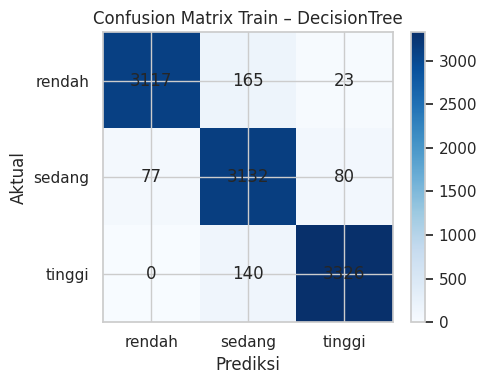

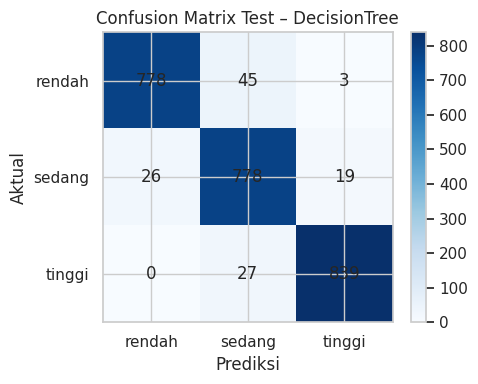

DecisionTree — Acc Train: 0.9518, Acc Test: 0.9523

=== Training RandomForest ===

=== CLASSIFICATION REPORT TRAIN ===
              precision    recall  f1-score   support

      rendah       0.82      0.82      0.82      3305
      sedang       0.88      0.22      0.35      3289
      tinggi       0.58      1.00      0.74      3466

    accuracy                           0.69     10060
   macro avg       0.76      0.68      0.64     10060
weighted avg       0.76      0.69      0.64     10060


=== CLASSIFICATION REPORT TEST ===
              precision    recall  f1-score   support

      rendah       0.83      0.80      0.81       826
      sedang       0.83      0.20      0.33       823
      tinggi       0.57      1.00      0.73       866

    accuracy                           0.67      2515
   macro avg       0.74      0.67      0.62      2515
weighted avg       0.74      0.67      0.62      2515


=== TABEL REPORT TRAIN ===


,precision,recall,f1-score,support,accuracy
rendah,0.823852,0.819365,0.821602,3305.0,0.685586
sedang,0.875449,0.222256,0.354510,3289.0,0.685586
tinggi,0.582351,0.997692,0.735432,3466.0,0.685586



=== TABEL REPORT TEST ===


,precision,recall,f1-score,support,accuracy
rendah,0.827068,0.799031,0.812808,826.0,0.672763
sedang,0.831683,0.204131,0.327805,823.0,0.672763
tinggi,0.570297,0.997691,0.725745,866.0,0.672763


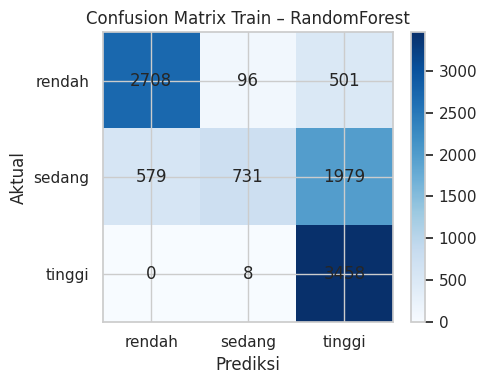

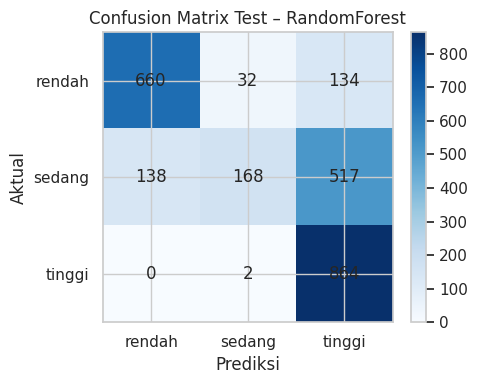

RandomForest — Acc Train: 0.6856, Acc Test: 0.6728

=== Training XGBoost ===

=== CLASSIFICATION REPORT TRAIN ===
              precision    recall  f1-score   support

      rendah       1.00      0.98      0.99      3305
      sedang       0.98      0.98      0.98      3289
      tinggi       0.98      0.99      0.98      3466

    accuracy                           0.98     10060
   macro avg       0.98      0.98      0.98     10060
weighted avg       0.98      0.98      0.98     10060


=== CLASSIFICATION REPORT TEST ===
              precision    recall  f1-score   support

      rendah       1.00      0.98      0.99       826
      sedang       0.98      0.98      0.98       823
      tinggi       0.98      0.99      0.99       866

    accuracy                           0.98      2515
   macro avg       0.98      0.98      0.98      2515
weighted avg       0.98      0.98      0.98      2515


=== TABEL REPORT TRAIN ===


,precision,recall,f1-score,support,accuracy
rendah,0.996006,0.980938,0.988415,3305.0,0.983101
sedang,0.976053,0.979021,0.977535,3289.0,0.983101
tinggi,0.977752,0.989036,0.983362,3466.0,0.983101



=== TABEL REPORT TEST ===


,precision,recall,f1-score,support,accuracy
rendah,0.996305,0.979419,0.987790,826.0,0.983698
sedang,0.976914,0.976914,0.976914,823.0,0.983698
tinggi,0.978409,0.994226,0.986254,866.0,0.983698


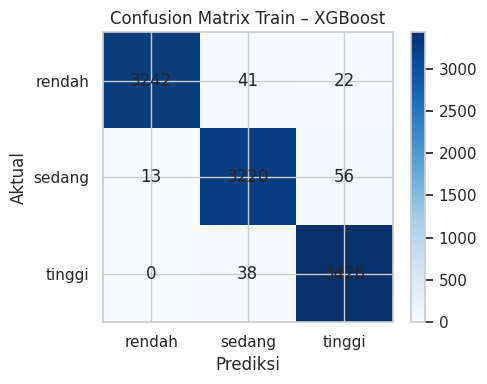

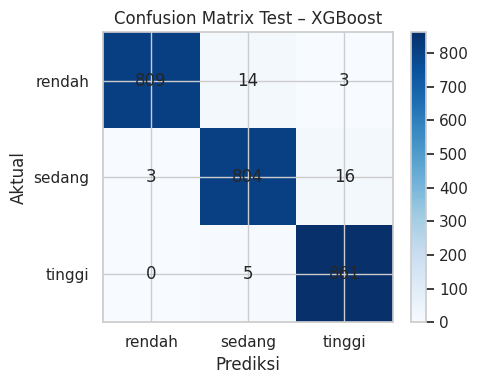

XGBoost — Acc Train: 0.9831, Acc Test: 0.9837

=== RINGKASAN AKHIR SEMUA MODEL ===


,model,acc_train,acc_test,train_time_s,predict_time_s,memory_increase_MB
2,XGBoost,0.983101,0.983698,200.806663,1.316495,509.886719
0,DecisionTree,0.951789,0.952286,6.184594,1.076233,3.125000
1,RandomForest,0.685586,0.672763,13.956517,1.354962,3.421875


In [ ]:
# ===============================
# MODELING & EVALUATION (SATU BLOK)
# ===============================

import os
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import xgboost as xgb

# ===============================
# DEFINISI MODEL
# ===============================

models = {
    'DecisionTree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        max_depth=4,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        reg_alpha=1,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42
    )
}

# ===============================
# FUNGSI TRAIN & EVALUASI
# ===============================

def train_and_evaluate(clf, name, X_train, y_train, X_test, y_test, preprocessor):
    proc = psutil.Process(os.getpid())
    mem_before = proc.memory_info().rss
    t0 = time.perf_counter()

    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', clf)
    ])

    pipe.fit(X_train, y_train)
    t1 = time.perf_counter()

    y_pred_train = pipe.predict(X_train)
    y_pred_test  = pipe.predict(X_test)
    t2 = time.perf_counter()

    mem_after = proc.memory_info().rss

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test, y_pred_test)

    report_train = classification_report(y_train, y_pred_train, output_dict=True)
    report_test  = classification_report(y_test, y_pred_test, output_dict=True)

    cm_train = confusion_matrix(y_train, y_pred_train, labels=[0,1,2])
    cm_test  = confusion_matrix(y_test, y_pred_test,  labels=[0,1,2])

    print("\n=== CLASSIFICATION REPORT TRAIN ===")
    print(classification_report(
        y_train, y_pred_train,
        target_names=['rendah','sedang','tinggi']
    ))

    print("\n=== CLASSIFICATION REPORT TEST ===")
    print(classification_report(
        y_test, y_pred_test,
        target_names=['rendah','sedang','tinggi']
    ))

    # ===== TABEL REPORT TRAIN =====
    print("\n=== TABEL REPORT TRAIN ===")
    df_train = pd.DataFrame(report_train).T.iloc[:3]
    df_train.index = ['rendah','sedang','tinggi']
    df_train['accuracy'] = report_train['accuracy']
    display(df_train)

    # ===== TABEL REPORT TEST =====
    print("\n=== TABEL REPORT TEST ===")
    df_test = pd.DataFrame(report_test).T.iloc[:3]
    df_test.index = ['rendah','sedang','tinggi']
    df_test['accuracy'] = report_test['accuracy']
    display(df_test)

    # CONFUSION MATRIX TRAIN
    plt.figure(figsize=(5,4))
    plt.imshow(cm_train, cmap='Blues')
    plt.title(f"Confusion Matrix Train – {name}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.xticks([0,1,2], ['rendah','sedang','tinggi'])
    plt.yticks([0,1,2], ['rendah','sedang','tinggi'])
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm_train[i,j], ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # CONFUSION MATRIX TEST
    plt.figure(figsize=(5,4))
    plt.imshow(cm_test, cmap='Blues')
    plt.title(f"Confusion Matrix Test – {name}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.xticks([0,1,2], ['rendah','sedang','tinggi'])
    plt.yticks([0,1,2], ['rendah','sedang','tinggi'])
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm_test[i,j], ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return {
        'model': name,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'train_time_s': t1 - t0,
        'predict_time_s': t2 - t1,
        'memory_increase_MB': (mem_after - mem_before) / (1024*1024)
    }

# ===============================
# JALANKAN SEMUA MODEL
# ===============================

results = []

for name, clf in models.items():
    print(f"\n=== Training {name} ===")
    res = train_and_evaluate(
        clf, name,
        X_train, y_train,
        X_test, y_test,
        preprocessor
    )
    results.append(res)
    print(f"{name} — Acc Train: {res['acc_train']:.4f}, Acc Test: {res['acc_test']:.4f}")

# ===============================
# RINGKASAN AKHIR
# ===============================

res_df = pd.DataFrame(results)

print("\n=== RINGKASAN AKHIR SEMUA MODEL ===")
display(res_df.sort_values(by='acc_test', ascending=False))


# PLOTS COMPARISON: Accuracy, Time, Memory


 PLOT 1 : Perbandingan Akurasi TRAIN


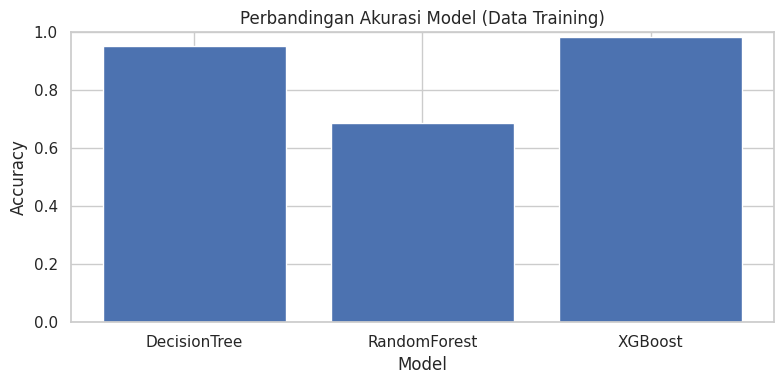


Keterangan:
- Grafik ini menunjukkan akurasi model pada data TRAINING transaksi.
- Akurasi TRAIN yang terlalu tinggi dibanding TEST dapat mengindikasikan overfitting.

----------------------------------------------------------------------

 PLOT 2 : Perbandingan Akurasi TEST


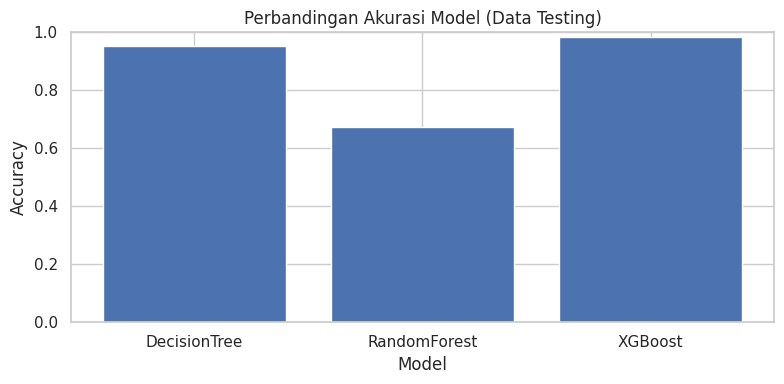


Keterangan:
- Grafik ini menunjukkan kemampuan model dalam menggeneralisasi data transaksi baru.
- Model yang baik memiliki akurasi TEST tinggi dan stabil.

----------------------------------------------------------------------

 PLOT 3 : Perbandingan Akurasi Train vs Test


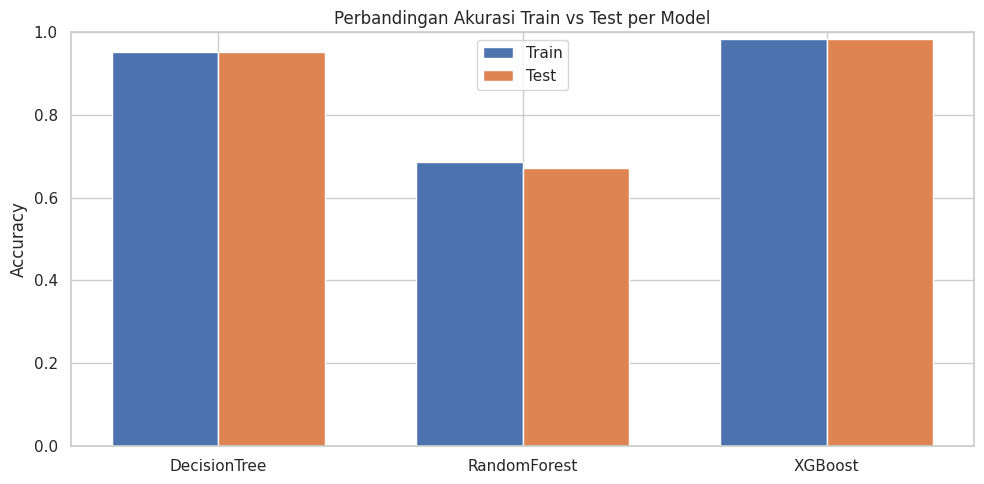


Keterangan:
- Grafik ini membandingkan performa model pada data TRAIN dan TEST.
- Selisih besar → indikasi overfitting.
- Selisih kecil → model lebih stabil dan generalisasi lebih baik.

----------------------------------------------------------------------

 PLOT 4 : Perbandingan Waktu Training


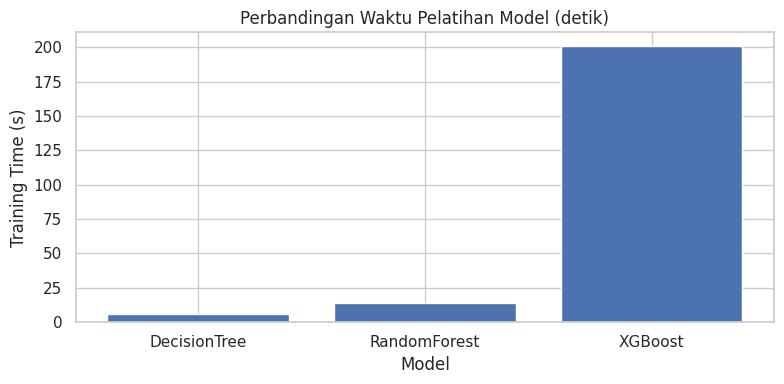


Keterangan:
- Menunjukkan waktu yang dibutuhkan setiap model untuk dilatih.
- Model kompleks seperti XGBoost umumnya memerlukan waktu lebih lama.

----------------------------------------------------------------------

 PLOT 5 : Perbandingan Penggunaan Memori


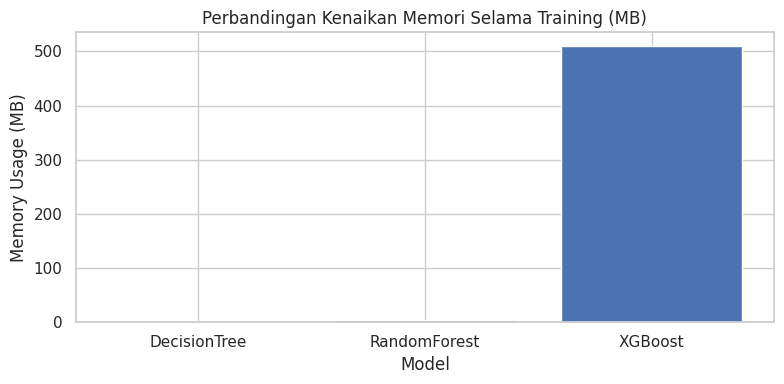


Keterangan:
- Menunjukkan tambahan penggunaan RAM oleh masing-masing model saat training.
- RandomForest dan XGBoost umumnya menggunakan memori lebih besar.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PLOTS COMPARISON (TRAIN & TEST)
# ===============================

# ===============================
# 1) AKURASI TRAIN
# ===============================
print("\n" + "="*70)
print(" PLOT 1 : Perbandingan Akurasi TRAIN")
print("="*70)

plt.figure(figsize=(8,4))
plt.bar(res_df['model'], res_df['acc_train'])
plt.title("Perbandingan Akurasi Model (Data Training)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(
    "\nKeterangan:\n"
    "- Grafik ini menunjukkan akurasi model pada data TRAINING transaksi.\n"
    "- Akurasi TRAIN yang terlalu tinggi dibanding TEST dapat mengindikasikan overfitting.\n"
)

print("-"*70)

# ===============================
# 2) AKURASI TEST
# ===============================
print("\n" + "="*70)
print(" PLOT 2 : Perbandingan Akurasi TEST")
print("="*70)

plt.figure(figsize=(8,4))
plt.bar(res_df['model'], res_df['acc_test'])
plt.title("Perbandingan Akurasi Model (Data Testing)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(
    "\nKeterangan:\n"
    "- Grafik ini menunjukkan kemampuan model dalam menggeneralisasi data transaksi baru.\n"
    "- Model yang baik memiliki akurasi TEST tinggi dan stabil.\n"
)

print("-"*70)

# ===============================
# 3) TRAIN vs TEST ACCURACY
# ===============================
print("\n" + "="*70)
print(" PLOT 3 : Perbandingan Akurasi Train vs Test")
print("="*70)

x = np.arange(len(res_df))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, res_df['acc_train'], width, label='Train')
plt.bar(x + width/2, res_df['acc_test'], width, label='Test')
plt.xticks(x, res_df['model'])
plt.title("Perbandingan Akurasi Train vs Test per Model")
plt.ylabel("Accuracy")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(
    "\nKeterangan:\n"
    "- Grafik ini membandingkan performa model pada data TRAIN dan TEST.\n"
    "- Selisih besar → indikasi overfitting.\n"
    "- Selisih kecil → model lebih stabil dan generalisasi lebih baik.\n"
)

print("-"*70)

# ===============================
# 4) WAKTU TRAINING
# ===============================
print("\n" + "="*70)
print(" PLOT 4 : Perbandingan Waktu Training")
print("="*70)

plt.figure(figsize=(8,4))
plt.bar(res_df['model'], res_df['train_time_s'])
plt.title("Perbandingan Waktu Pelatihan Model (detik)")
plt.ylabel("Training Time (s)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

print(
    "\nKeterangan:\n"
    "- Menunjukkan waktu yang dibutuhkan setiap model untuk dilatih.\n"
    "- Model kompleks seperti XGBoost umumnya memerlukan waktu lebih lama.\n"
)

print("-"*70)

# ===============================
# 5) PENGGUNAAN MEMORI
# ===============================
print("\n" + "="*70)
print(" PLOT 5 : Perbandingan Penggunaan Memori")
print("="*70)

plt.figure(figsize=(8,4))
plt.bar(res_df['model'], res_df['memory_increase_MB'])
plt.title("Perbandingan Kenaikan Memori Selama Training (MB)")
plt.ylabel("Memory Usage (MB)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

print(
    "\nKeterangan:\n"
    "- Menunjukkan tambahan penggunaan RAM oleh masing-masing model saat training.\n"
    "- RandomForest dan XGBoost umumnya menggunakan memori lebih besar.\n"
)

print("="*70 + "\n")

##1. Performa Model

**A. Decision Tree**

- Train Accuracy: 0.9518

- Test Accuracy: 0.9523

- Overfitting: sangat rendah

Model Decision Tree menunjukkan performa yang sangat baik dan konsisten pada data latih maupun data uji. Nilai akurasi train dan test yang hampir identik mengindikasikan bahwa model mampu mempelajari pola transaksi tanpa mengalami overfitting. Model juga memiliki nilai precision, recall, dan f1-score yang tinggi pada seluruh kelas (rendah, sedang, tinggi), meskipun performa sedikit lebih rendah pada kelas sedang dibanding kelas lainnya.

**Interpretasi:**

Decision Tree sangat layak digunakan sebagai baseline model karena memiliki performa tinggi, stabil, dan mudah diinterpretasikan, terutama untuk menjelaskan pengaruh fitur transaksi terhadap kelas pengeluaran.

**B. Random Forest**

- Train Accuracy: 0.6856

- Test Accuracy: 0.6728

- Stabilitas: moderat

Random Forest menunjukkan performa yang lebih rendah dibanding Decision Tree dan XGBoost. Model mampu mengklasifikasikan kelas tinggi dengan sangat baik (recall mendekati 1.00), namun mengalami kesulitan signifikan pada kelas sedang, yang ditunjukkan oleh nilai recall dan f1-score yang rendah. Hal ini mengindikasikan adanya tumpang tindih pola fitur pada kelas menengah.

**Interpretasi:**

Meskipun secara teori Random Forest bersifat stabil, pada dataset ini model belum optimal dalam membedakan kelas transaksi, khususnya kelas sedang, sehingga kurang cocok sebagai model utama tanpa tuning lanjutan.

**C. XGBoost**

- Train Accuracy: 0.9831

- Test Accuracy: 0.9837

- Model terbaik

- Overfitting: terkendali

XGBoost menghasilkan performa tertinggi di antara seluruh model. Akurasi train dan test yang sangat tinggi serta selisih yang kecil menunjukkan kemampuan generalisasi yang sangat baik. Model mampu menangkap hubungan non-linear antar fitur transaksi seperti harga, kuantitas, diskon, dan total belanja, serta membedakan seluruh kelas pengeluaran dengan presisi yang sangat tinggi.


**Interpretasi:**

XGBoost merupakan model paling optimal untuk dataset ini karena memberikan kombinasi terbaik antara akurasi, stabilitas, dan kemampuan generalisasi.

2. Analisis Perbedaan Akurasi Model
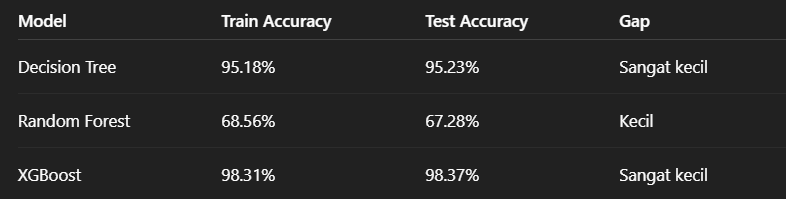

- Train Accuracy: XGBoost > Decision Tree > Random Forest

- Test Accuracy: XGBoost tetap paling tinggi, menunjukkan generalisasi terbaik.

- Decision Tree stabil namun akurasinya masih di bawah XGBoost.

- Random Forest memiliki performa paling rendah pada dataset ini.

**3. Waktu Pelatihan**

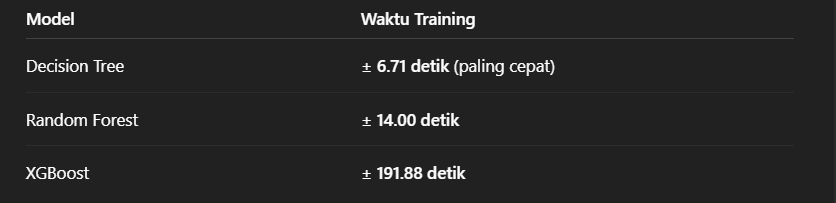

Meskipun XGBoost membutuhkan waktu pelatihan paling lama, seluruh model masih tergolong efisien untuk dataset berukuran kecil–menengah.

4. Penggunaan Memori Model

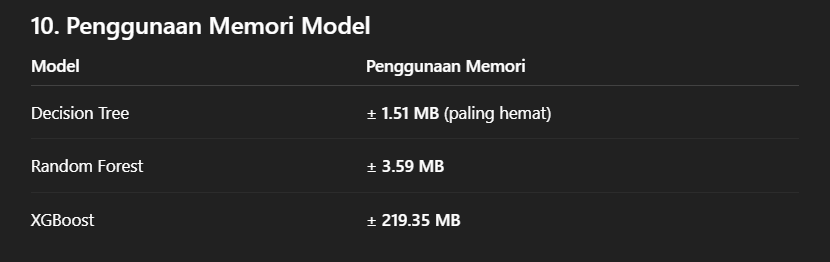

XGBoost memerlukan sumber daya memori paling besar, namun penggunaan tersebut sebanding dengan peningkatan akurasi yang signifikan.

**Kesimpulan Akhir:**

Dataset penjualan ritel memiliki kualitas data yang baik setelah proses pembersihan dan preprocessing. Distribusi fitur numerik dan kategorikal seimbang, serta pembagian data train–test stratified berhasil menjaga proporsi kelas pengeluaran (rendah, sedang, tinggi).

**Perbandingan model menunjukkan:**

- Decision Tree: baseline yang kuat, stabil, dan mudah diinterpretasikan.

- Random Forest: performa moderat namun kurang optimal pada kelas menengah.

- XGBoost: model terbaik dengan akurasi dan generalisasi tertinggi.

Seluruh model menunjukkan gap akurasi train–test yang kecil, menandakan overfitting minimal. Dari sisi komputasi, semua model masih layak digunakan, dengan XGBoost sebagai pilihan utama ketika akurasi menjadi prioritas.

## 7. Save Cleaned Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Tentukan path di Google Drive tempat ingin menyimpan dataset bersih
clean_path = "/content/drive/MyDrive/Lab Data Science/cleaned_retail_store_sales.xlsx"  # ganti nama file sesuai keinginan

# Simpan DataFrame df yang sudah dibersihkan ke file Excel
df.to_excel(clean_path, index=False)

print("Cleaned dataset saved at:", clean_path)


Cleaned dataset saved at: /content/drive/MyDrive/Lab Data Science/cleaned_retail_store_sales.xlsx
